# Preparação e transformação de dados

**Francisco Aparecido Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Em Ciência de Dados, a qualidade do modelo depende diretamente da qualidade dos dados. Por isso, a preparação dos dados costuma ser uma das etapas mais importantes de um projeto.

Neste notebook, vamos considerar as seguintes etapas:
1. identificar problemas comuns em bases de dados, como valores ausentes, duplicatas e registros inconsistentes;
2. aplicar procedimentos básicos de limpeza usando `pandas` e `numpy`;
3. substituir valores ausentes por medidas como média e mediana;
4. normalizar e padronizar atributos numéricos;
5. converter variáveis categóricas em variáveis numéricas;
6. identificar variáveis altamente correlacionadas;
7. avaliar desbalanceamento de classes.

### 1. Bibliotecas utilizadas

Nesta aula, usaremos principalmente:

- `pandas`: leitura, organização e manipulação de tabelas;
- `numpy`: operações numéricas e vetoriais;
- `matplotlib` e `seaborn`: visualização de dados;
- `scikit-learn`: métodos de pré-processamento, como normalização e padronização.

Também definimos uma semente aleatória para garantir que os resultados possam ser reproduzidos.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Alguns exemplos usam gráficos estatísticos da biblioteca seaborn.
import seaborn as sns

# Define sementes aleatórias para reprodutibilidade.
random.seed(1)
np.random.seed(1)

# Configuração simples para melhorar a visualização das tabelas.
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

ModuleNotFoundError: No module named 'seaborn'

### 2. Leitura de uma base com problemas

Vamos iniciar com uma versão modificada da base **Iris**, contendo alguns problemas artificiais, como:

- valores ausentes representados por `NaN`;
- valores faltantes representados pelo caractere `?`;
- linhas duplicadas.

Esse tipo de situação é comum em bases reais, especialmente quando os dados foram coletados manualmente ou integrados a partir de diferentes fontes.

In [ ]:
# Lê uma base de dados com alguns erros introduzidos artificialmente.
data = pd.read_csv("data/iris-with-errors.csv", header=0)

print("Número de linhas e colunas:", data.shape)
data.head(10)

Número de linhas e colunas: (25, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,?,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
5,NaN,3.1,1.5,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
9,4.6,3.4,1.4,NaN,setosa


Antes de aplicar qualquer técnica estatística ou algoritmo de aprendizado de máquina, é importante **inspecionar os dados**.

Algumas perguntas úteis são:

- Quantas linhas e colunas existem?
- Quais são os nomes das variáveis?
- Quais colunas são numéricas e quais são categóricas?
- Há valores ausentes?
- Há registros duplicados?

In [ ]:
print("Colunas da base:")
print(data.columns)

print("\nTipos de dados:")
print(data.dtypes)

print("\nQuantidade de valores ausentes por coluna:")
print(data.isna().sum())

print("\nNúmero de linhas duplicadas:", data.duplicated().sum())

Colunas da base:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'], dtype='object')

Tipos de dados:
sepal_length     object
sepal_width      object
petal_length    float64
petal_width      object
species          object
dtype: object

Quantidade de valores ausentes por coluna:
sepal_length    2
sepal_width     0
petal_length    0
petal_width     1
species         0
dtype: int64

Número de linhas duplicadas: 5


### 3. Remoção de valores ausentes

Uma primeira estratégia para lidar com valores ausentes é remover as linhas que contêm `NaN`.

Essa estratégia é simples, mas deve ser usada com cuidado. Se muitas linhas forem removidas, podemos perder uma parte importante da informação disponível.

In [ ]:
# Cria uma cópia para preservar a base original.
data_sem_nan = data.dropna()

print("Dimensão original:", data.shape)
print("Dimensão após remover NaN:", data_sem_nan.shape)

data_sem_nan.head(25)

Dimensão original: (25, 5)
Dimensão após remover NaN: (22, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,?,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada


### 4. Identificação e remoção de linhas duplicadas

Linhas duplicadas podem ocorrer por erro de registro, repetição de entrada ou união incorreta de bases. Em alguns casos, duplicatas são legítimas; em outros, devem ser removidas.

A função `duplicated()` indica quais linhas já apareceram anteriormente na tabela.

In [ ]:
# Verifica quais linhas são duplicadas.
linhas_duplicadas = data_sem_nan.duplicated()
linhas_duplicadas.head(25)

0     False
1      True
2     False
3     False
4      True
6     False
7     False
8      True
10    False
11    False
12    False
13    False
14     True
15    False
16    False
17     True
18    False
19    False
20    False
21    False
22    False
23    False
dtype: bool

Vamos fazer a remoção das linhas duplicadas.

In [ ]:
print("Número de linhas duplicadas:", linhas_duplicadas.sum())

# Remove as linhas duplicadas.
data_limpa = data_sem_nan.drop_duplicates()

print("Dimensão antes da remoção:", data_sem_nan.shape)
print("Dimensão depois da remoção:", data_limpa.shape)

data_limpa.head(25)

Número de linhas duplicadas: 5
Dimensão antes da remoção: (22, 5)
Dimensão depois da remoção: (17, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
2,?,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada
12,4.9,3.1,1.5,0.1,setosa
13,5.4,3.7,1.5,0.2,setosa
15,4.8,3.4,1.6,0.2,setosa


### 5. Tratamento de valores faltantes

Nem sempre valores faltantes aparecem como `NaN`. Em muitas bases, eles podem ser representados por símbolos como:

- `?`
- `-`
- `NA`
- `None`
- espaço em branco

Neste exemplo, vamos substituir `?` por `np.nan`, que é a representação padrão de valor ausente usada pelo `numpy` e pelo `pandas`.

In [ ]:
# Lê novamente a base com erros para refazer o processo de forma completa.
data = pd.read_csv("data/iris-with-errors.csv", header=0)

# Substitui o caractere '?' por NaN.
data = data.replace("?", np.nan)

print("Valores ausentes por coluna após substituir '?':")
print(data.isna().sum())

data.head(25)

Valores ausentes por coluna após substituir '?':
sepal_length    3
sepal_width     1
petal_length    0
petal_width     2
species         0
dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,NaN,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
5,NaN,3.1,1.5,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
9,4.6,3.4,1.4,NaN,setosa


Agora podemos remover as linhas com valores ausentes usando `dropna()`.

Notem que remover linhas é apenas uma das possibilidades. Em algumas situações, pode ser melhor substituir os valores ausentes por média, mediana, moda ou por valores estimados por algum modelo.

In [ ]:
data_limpa = data.dropna().drop_duplicates()

print("Dimensão original:", data.shape)
print("Dimensão após limpeza:", data_limpa.shape)

data_limpa.head(25)

Dimensão original: (25, 5)
Dimensão após limpeza: (14, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
3,4.7,3.2,1.3,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada
12,4.9,3.1,1.5,0.1,setosa
13,5.4,3.7,1.5,0.2,setosa
15,4.8,3.4,1.6,0.2,setosa
16,4.8,3,1.4,0.1,setosa


### 6. Remoção de linhas e colunas específicas

Em algumas análises, pode ser necessário remover colunas irrelevantes ou linhas específicas. Para isso, usamos o método `drop()`.

No `pandas`:

- `axis=0` indica remoção de linhas;
- `axis=1` indica remoção de colunas.

A seguir, removemos a segunda e a quarta colunas apenas para ilustrar o procedimento.

In [ ]:
# Cria uma cópia para não alterar definitivamente a base limpa.
exemplo_drop = data_limpa.copy()

print("Atributos atuais:", list(exemplo_drop.columns))
print("Colunas que serão removidas:", list(exemplo_drop.columns[[1, 3]]))

exemplo_drop = exemplo_drop.drop(exemplo_drop.columns[[1, 3]], axis=1)
exemplo_drop.head(25)

Atributos atuais: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Colunas que serão removidas: ['sepal_width', 'petal_width']


,sepal_length,petal_length,species
0,5.1,1.4,duplicada
3,4.7,1.3,setosa
6,5,1.4,setosa
7,5.4,1.7,duplicada
10,5,1.5,setosa
11,4.4,1.4,duplicada
12,4.9,1.5,setosa
13,5.4,1.5,setosa
15,4.8,1.6,setosa
16,4.8,1.4,setosa


Também podemos remover linhas específicas usando seus índices.

In [ ]:
data_limpa.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
3,4.7,3.2,1.3,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada
12,4.9,3.1,1.5,0.1,setosa
13,5.4,3.7,1.5,0.2,setosa
15,4.8,3.4,1.6,0.2,setosa
16,4.8,3,1.4,0.1,setosa


In [ ]:
exemplo_drop_linhas = data_limpa.copy()

indices_removidos = exemplo_drop_linhas.index[[0, 2, 5]]
print("Índices que serão removidos:", list(indices_removidos))

exemplo_drop_linhas = exemplo_drop_linhas.drop(indices_removidos, 
                                               axis=0)
exemplo_drop_linhas.head(25)

Índices que serão removidos: [0, 6, 11]


,sepal_length,sepal_width,petal_length,petal_width,species
3,4.7,3.2,1.3,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
12,4.9,3.1,1.5,0.1,setosa
13,5.4,3.7,1.5,0.2,setosa
15,4.8,3.4,1.6,0.2,setosa
16,4.8,3,1.4,0.1,setosa
18,4.3,3,1.1,0.1,setosa
19,5.8,4,1.2,0.2,setosa
20,5.7,4.4,1.5,0.4,setosa


### 7. Substituição de valores ausentes

Remover linhas com valores ausentes pode ser inadequado quando a base é pequena ou quando há muitos dados faltantes.

Uma alternativa é substituir os valores ausentes por alguma medida representativa da coluna, como:

- média;
- mediana;
- moda;
- valor fixo;
- valor estimado por um modelo.

Neste exemplo, vamos substituir os valores ausentes pela **média de cada atributo numérico**.

In [ ]:
data = pd.read_csv("data/iris-with-errors.csv", header=0)
data = data.replace("?", np.nan)

print("Dimensão da base:", data.shape)
data.head(25)

Dimensão da base: (25, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,NaN,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
5,NaN,3.1,1.5,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
9,4.6,3.4,1.4,NaN,setosa


Primeiro, separamos apenas as variáveis numéricas. A última coluna contém a classe da flor e, portanto, não deve ser usada no cálculo da média dos atributos.

In [ ]:
# Seleciona todas as colunas, exceto a última, e converte para float.
X = np.array(data[data.columns[:-1]], dtype=float)

# Calcula a média de cada coluna, ignorando os valores NaN.
medias = np.nanmean(X, axis=0)

print("Média de cada atributo:")
print(medias)

# Substitui cada NaN pela média da respectiva coluna.
X_preenchido = X.copy()
for i in range(X_preenchido.shape[0]):
    for j in range(X_preenchido.shape[1]):
        if np.isnan(X_preenchido[i, j]):
            X_preenchido[i, j] = medias[j]
            #X_preenchido[i, j] = -10

print("\nMatriz após substituição dos valores ausentes:")
print(X_preenchido)

Média de cada atributo:
[5.02272727 3.4375     1.44       0.22608696]

Matriz após substituição dos valores ausentes:
[[5.1        3.5        1.4        0.2       ]
 [5.1        3.5        1.4        0.2       ]
 [5.02272727 3.         1.4        0.2       ]
 [4.7        3.2        1.3        0.2       ]
 [5.1        3.5        1.4        0.2       ]
 [5.02272727 3.1        1.5        0.2       ]
 [5.         3.6        1.4        0.2       ]
 [5.4        3.9        1.7        0.4       ]
 [5.4        3.9        1.7        0.4       ]
 [4.6        3.4        1.4        0.22608696]
 [5.         3.4        1.5        0.2       ]
 [4.4        2.9        1.4        0.2       ]
 [4.9        3.1        1.5        0.1       ]
 [5.4        3.7        1.5        0.2       ]
 [4.4        2.9        1.4        0.2       ]
 [4.8        3.4        1.6        0.2       ]
 [4.8        3.         1.4        0.1       ]
 [4.4        2.9        1.4        0.2       ]
 [4.3        3.         1.1        0

Podemos reconstruir um `DataFrame` do `pandas` a partir da matriz preenchida.

In [ ]:
df_preenchido = pd.DataFrame(X_preenchido, 
                             columns=list(data.columns[:-1]))
df_preenchido.head(10)

,sepal_length,sepal_width,petal_length,petal_width
0,5.100000,3.5,1.4,0.200000
1,5.100000,3.5,1.4,0.200000
2,5.022727,3.0,1.4,0.200000
3,4.700000,3.2,1.3,0.200000
4,5.100000,3.5,1.4,0.200000
5,5.022727,3.1,1.5,0.200000
6,5.000000,3.6,1.4,0.200000
7,5.400000,3.9,1.7,0.400000
8,5.400000,3.9,1.7,0.400000
9,4.600000,3.4,1.4,0.226087


O mesmo procedimento anterior pode ser feito de forma mais compacta usando `fillna()`.

Essa forma é muito comum em projetos de Ciência de Dados.

In [ ]:
data = pd.read_csv("data/iris-with-errors.csv", header=0)
data = data.replace("?", np.nan)

atributos = data.columns[:-1]

# Converte as colunas de atributos para valores numéricos.
data[atributos] = data[atributos].astype(float)

# Substitui os valores ausentes pela média de cada coluna.
data_media = data.copy()
data_media[atributos] = data_media[atributos].fillna(data_media[atributos].mean())
#data_media[atributos] = data_media[atributos].fillna(-10)

data_media.head(25)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.100000,3.5000,1.4,0.200000,duplicada
1,5.100000,3.5000,1.4,0.200000,duplicada
2,5.022727,3.0000,1.4,0.200000,setosa
3,4.700000,3.2000,1.3,0.200000,setosa
4,5.100000,3.5000,1.4,0.200000,duplicada
5,5.022727,3.1000,1.5,0.200000,setosa
6,5.000000,3.6000,1.4,0.200000,setosa
7,5.400000,3.9000,1.7,0.400000,duplicada
8,5.400000,3.9000,1.7,0.400000,duplicada
9,4.600000,3.4000,1.4,0.226087,setosa


### 8. Normalização e padronização

Muitos algoritmos de aprendizado de máquina são sensíveis à escala dos atributos. Por exemplo, uma variável medida em milhares pode dominar outra variável medida entre 0 e 1.

Duas transformações muito usadas são:

### Normalização Min-Max

Transforma os dados para um intervalo fixo, geralmente \([0,1]\):

$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$

### Padronização

Transforma os dados para terem média zero e desvio padrão igual a um:

$
z = \frac{x - \mu}{\sigma}
$

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Lê a base Iris sem erros.
data = pd.read_csv("data/iris.csv", header=0)

print("Número de linhas e colunas:", data.shape)
data.head()

Número de linhas e colunas: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Vamos separar os atributos numéricos da variável de classe.

In [ ]:
# Considera somente os atributos, ignorando a última coluna, que contém a classe.
X = np.array(data[data.columns[:-1]], dtype=float)
y = data[data.columns[-1]]

print("Dimensão da matriz de atributos:", X.shape)
print("Classes:", np.unique(y))

Dimensão da matriz de atributos: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


#### 8.1 Normalização Min-Max

A normalização coloca cada atributo no intervalo \([0,1]\). Após a transformação, o menor valor de cada coluna passa a ser 0 e o maior valor passa a ser 1.

In [ ]:
for i in range(X.shape[1]):
    print(f"Coluna {i}: mínimo = {X[:, i].min():.2f}, máximo = {X[:, i].max():.2f}")

scaler_minmax = MinMaxScaler(feature_range=(0, 1))
X_norm = scaler_minmax.fit_transform(X)

print("\nDados normalizados:")
print(X_norm[:10])

Coluna 0: mínimo = 4.30, máximo = 7.90
Coluna 1: mínimo = 2.00, máximo = 4.40
Coluna 2: mínimo = 1.00, máximo = 6.90
Coluna 3: mínimo = 0.10, máximo = 2.50

Dados normalizados:
[[0.22222222 0.625      0.06779661 0.04166667]
 [0.16666667 0.41666667 0.06779661 0.04166667]
 [0.11111111 0.5        0.05084746 0.04166667]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]
 [0.30555556 0.79166667 0.11864407 0.125     ]
 [0.08333333 0.58333333 0.06779661 0.08333333]
 [0.19444444 0.58333333 0.08474576 0.04166667]
 [0.02777778 0.375      0.06779661 0.04166667]
 [0.16666667 0.45833333 0.08474576 0.        ]]


In [ ]:
print("Mínimo dos atributos normalizados:", np.amin(X_norm, axis=0))
print("Máximo dos atributos normalizados:", np.amax(X_norm, axis=0))

Mínimo dos atributos normalizados: [0. 0. 0. 0.]
Máximo dos atributos normalizados: [1. 1. 1. 1.]


#### 8.2 Padronização

Na padronização, cada coluna passa a ter média aproximadamente igual a 0 e desvio padrão aproximadamente igual a 1.

Essa transformação é especialmente importante em métodos baseados em distância, como k-vizinhos mais próximos, k-means e SVM.

In [ ]:
scaler_standard = StandardScaler()
X_padronizado = scaler_standard.fit_transform(X)

print("Dados padronizados:")
print(X_padronizado[:10])

Dados padronizados:
[[-0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.38535265  0.33784833 -1.39813811 -1.31297673]
 [-1.50652052  0.10644536 -1.2844067  -1.31297673]
 [-1.02184904  1.26346019 -1.3412724  -1.31297673]
 [-0.53717756  1.95766909 -1.17067529 -1.05003079]
 [-1.50652052  0.80065426 -1.3412724  -1.18150376]
 [-1.02184904  0.80065426 -1.2844067  -1.31297673]
 [-1.74885626 -0.35636057 -1.3412724  -1.31297673]
 [-1.14301691  0.10644536 -1.2844067  -1.4444497 ]]


In [ ]:
for i in range(X_padronizado.shape[1]):
    print(f"Coluna {i}: média = {np.mean(X_padronizado[:, i]):.4f}")
    print(f"Coluna {i}: desvio padrão = {np.std(X_padronizado[:, i]):.4f}\n")

Coluna 0: média = -0.0000
Coluna 0: desvio padrão = 1.0000

Coluna 1: média = -0.0000
Coluna 1: desvio padrão = 1.0000

Coluna 2: média = 0.0000
Coluna 2: desvio padrão = 1.0000

Coluna 3: média = -0.0000
Coluna 3: desvio padrão = 1.0000



#### 8.3 Comparação visual

Os histogramas abaixo ajudam a comparar os dados originais, normalizados e padronizados.

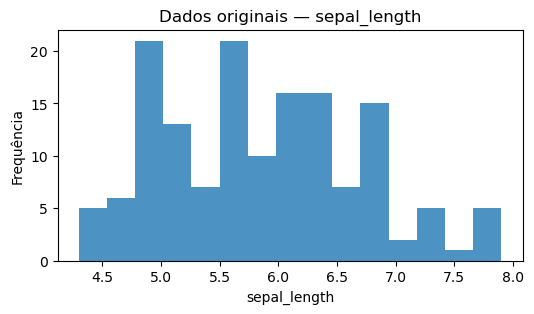

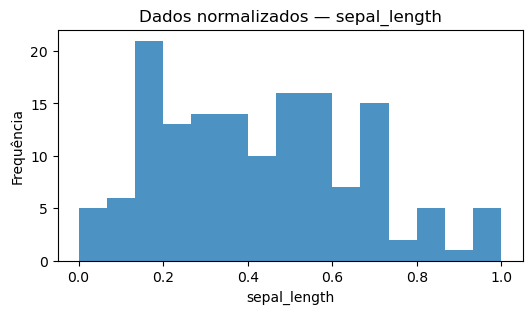

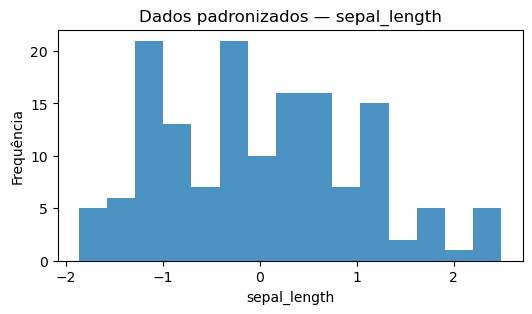

In [ ]:
coluna = 0
nome_coluna = data.columns[coluna]

plt.figure(figsize=(6, 3))
plt.hist(X[:, coluna], bins=15, alpha=0.8)
plt.title(f"Dados originais — {nome_coluna}")
plt.xlabel(nome_coluna)
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(6, 3))
plt.hist(X_norm[:, coluna], bins=15, alpha=0.8)
plt.title(f"Dados normalizados — {nome_coluna}")
plt.xlabel(nome_coluna)
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(6, 3))
plt.hist(X_padronizado[:, coluna], bins=15, alpha=0.8)
plt.title(f"Dados padronizados — {nome_coluna}")
plt.xlabel(nome_coluna)
plt.ylabel("Frequência")
plt.show()

### 9. Binarização dos dados

A binarização transforma valores numéricos em 0 ou 1 a partir de um limiar \(T\):

$$
X_{novo}(i,j) = 
\begin{cases} 
1, & \text{se } X(i,j) \geq T \\ 
0, & \text{se } X(i,j) < T 
\end{cases}
$$


Esse procedimento pode ser útil quando queremos transformar uma medida contínua em uma variável indicadora.

In [ ]:
from sklearn.preprocessing import Binarizer

T = 0.2
print("Limiar:", T)
print("---------------------")

# Primeiro normalizamos os dados para o intervalo [0, 1].
X_norm = MinMaxScaler(feature_range=(0, 1)).fit_transform(X)

# Depois aplicamos a binarização.
binarizer = Binarizer(threshold=T)
X_binario = binarizer.fit_transform(X_norm)

for i in range(10):
    print("Antes:", X_norm[i])
    print("Depois:", X_binario[i])
    print("---------------------")

Limiar: 0.2
---------------------
Antes: [0.22222222 0.625      0.06779661 0.04166667]
Depois: [1. 1. 0. 0.]
---------------------
Antes: [0.16666667 0.41666667 0.06779661 0.04166667]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.11111111 0.5        0.05084746 0.04166667]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.08333333 0.45833333 0.08474576 0.04166667]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.19444444 0.66666667 0.06779661 0.04166667]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.30555556 0.79166667 0.11864407 0.125     ]
Depois: [1. 1. 0. 0.]
---------------------
Antes: [0.08333333 0.58333333 0.06779661 0.08333333]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.19444444 0.58333333 0.08474576 0.04166667]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.02777778 0.375      0.06779661 0.04166667]
Depois: [0. 1. 0. 0.]
---------------------
Antes: [0.16666667 0.45833333 0.08474576 0.        ]
Depois: [0. 1. 0. 0.]
------------------

### 10. Conversão de variáveis categóricas em inteiros

Algoritmos de aprendizado de máquina geralmente trabalham com números. Por isso, variáveis categóricas precisam ser codificadas.

No caso da base Iris, a coluna `species` contém nomes de espécies. Podemos substituir cada espécie por um número inteiro.

> Atenção: essa codificação cria uma ordem artificial entre as classes. Para variáveis nominais sem ordem natural, muitas vezes o **one-hot encoding** é mais apropriado.

In [ ]:
data = pd.read_csv("data/iris.csv", header=0)

print("Coluna original com as classes:")
print(data[data.columns[-1]].head(10))

Coluna original com as classes:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
5    setosa
6    setosa
7    setosa
8    setosa
9    setosa
Name: species, dtype: object


In [ ]:
# Armazena os nomes das classes.
classes = np.unique(data[data.columns[-1]])

# Cria um dicionário de mapeamento: classe -> número.
mapeamento = {classe: numero for numero, classe in enumerate(classes)}
print("Mapeamento usado:", mapeamento)

# Substitui os nomes das classes por números.
data_codificada = data.copy()
data_codificada[data.columns[-1]] = data_codificada[data.columns[-1]].map(mapeamento)

print("\nColuna codificada:")
print(data_codificada[data.columns[-1]].head(10))

Mapeamento usado: {'setosa': 0, 'versicolor': 1, 'virginica': 2}

Coluna codificada:
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: species, dtype: int64


### 11. One-hot encoding

O **one-hot encoding** cria uma coluna binária para representar cada categoria. Esse procedimento evita introduzir uma ordem artificial entre categorias nominais.

Exemplo: se uma variável pode assumir os valores `a`, `b` e `c`, podemos criar colunas indicando se a observação pertence ou não a cada categoria.

In [ ]:
df = pd.DataFrame({
    "categoria": ["a", "b", "a", "c", "a", "b"]
})

df

,categoria
0,a
1,b
2,a
3,c
4,a
5,b


Usando `pd.get_dummies()`, obtemos as variáveis indicadoras. O argumento `drop_first=True` remove uma das categorias para evitar redundância perfeita entre colunas.

In [ ]:
df_onehot = pd.get_dummies(df, drop_first=True)
df_onehot

,categoria_b,categoria_c
0,False,False
1,True,False
2,False,False
3,False,True
4,False,False
5,True,False


### 12. Identificação de variáveis correlacionadas

Quando duas variáveis são muito correlacionadas, elas carregam informação semelhante. Isso pode gerar redundância e, em alguns modelos, instabilidade na estimativa dos parâmetros.

A seguir, vamos usar a base **Boston Housing** para calcular a matriz de correlação entre as variáveis.

In [ ]:
data = pd.read_csv("data/BostonHousing.csv", header=0)
print("Número de linhas e colunas:", data.shape)
data.head(10)

Número de linhas e colunas: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


A matriz de correlação mostra a associação linear entre pares de variáveis. Valores próximos de 1 indicam forte correlação positiva; valores próximos de -1 indicam forte correlação negativa; valores próximos de 0 indicam pouca associação linear.

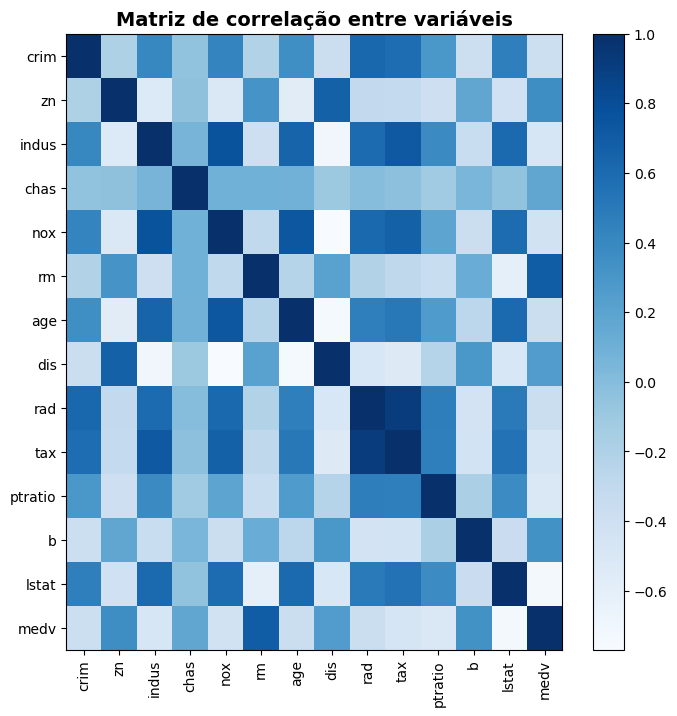

In [ ]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(8, 8))
plt.imshow(corr, cmap="Blues", interpolation="none", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation="vertical")
plt.yticks(range(len(corr)), corr.columns)
plt.title("Matriz de correlação entre variáveis", fontsize=14, fontweight="bold")
plt.grid(False)
plt.show()

In [ ]:
corr

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


Agora vamos identificar pares de variáveis cuja correlação absoluta é maior que um limiar \(p\).

In [ ]:
p = 0.75
pares_correlacionados = []

# Percorre apenas metade da matriz para evitar repetir pares.
for i, col_i in enumerate(corr.columns):
    for j, col_j in enumerate(corr.columns):
        if j > i and abs(corr.loc[col_i, col_j]) > p:
            pares_correlacionados.append((col_i, col_j, corr.loc[col_i, col_j]))

print(f"Pares com correlação absoluta maior que {p}:")
for col_i, col_j, valor in pares_correlacionados:
    print(f"{col_i} -- {col_j}: correlação = {valor:.3f}")

Pares com correlação absoluta maior que 0.75:
indus -- nox: correlação = 0.764
nox -- dis: correlação = -0.769
rad -- tax: correlação = 0.910


> Em uma aplicação real, a decisão de remover uma variável não deve depender apenas da correlação. Também devemos considerar o significado da variável, o objetivo da análise e o modelo que será usado.

### 13. Dados desbalanceados

Em problemas de classificação, é comum que algumas classes tenham muito mais observações do que outras. Esse problema é chamado de **desbalanceamento de classes**.

Quando os dados são muito desbalanceados, um classificador pode ter bom desempenho aparente simplesmente por favorecer a classe majoritária.

In [ ]:
data = pd.read_csv("data/Vehicle.csv", header=0)
print("Número de linhas e colunas:", data.shape)
data.head(10)

Número de linhas e colunas: (846, 19)


,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus
5,107,57,106,172,50,6,255,26,28,169,280,957,264,85,5,9,181,183,bus
6,97,43,73,173,65,6,153,42,19,143,176,361,172,66,13,1,200,204,bus
7,90,43,66,157,65,9,137,48,18,146,162,281,164,67,3,3,193,202,van
8,86,34,62,140,61,7,122,54,17,127,141,223,112,64,2,14,200,208,van
9,93,44,98,197,62,11,183,36,22,146,202,505,152,64,4,14,195,204,saab


In [ ]:
classes = data[data.columns[-1]]

print("Primeiros valores da coluna de classe:")
print(classes.head())

print("\nNúmero de elementos por classe:")
print(classes.value_counts())

Primeiros valores da coluna de classe:
0     van
1     van
2    saab
3     van
4     bus
Name: Class, dtype: object

Número de elementos por classe:
Class
bus     218
saab    217
opel    212
van     199
Name: count, dtype: int64


Podemos visualizar a quantidade de elementos em cada classe usando um gráfico de barras.

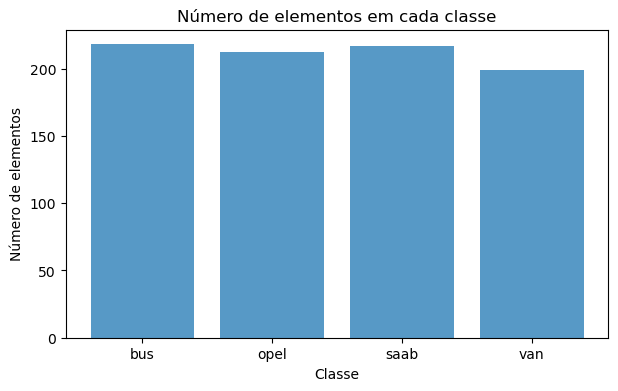

In [ ]:
contagem_classes = classes.value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(contagem_classes.index, contagem_classes.values, alpha=0.75)
plt.title("Número de elementos em cada classe")
plt.xlabel("Classe")
plt.ylabel("Número de elementos")
plt.show()

### Subamostragem simples

Uma forma simples de balancear os dados é selecionar o mesmo número de elementos de cada classe. Essa técnica é chamada de **subamostragem** da classe majoritária.

No exemplo abaixo, selecionamos \(N\) observações de cada classe, sem reposição.

> Esta técnica pode descartar dados importantes. Em problemas reais, também podemos considerar outras estratégias, como sobreamostragem, SMOTE ou uso de métricas adequadas para dados desbalanceados.

In [ ]:
N = 5

X = np.array(data)
cls = np.array(data[data.columns[-1]])
classes_unicas = np.unique(cls)

amostras = []
for classe in classes_unicas:
    indices_classe = np.argwhere(cls == classe).ravel()
    indices_sorteados = np.random.choice(indices_classe, N, replace=False)
    amostras.append(X[indices_sorteados, :])

X_balanceado = np.vstack(amostras)

print("Dados obtidos a partir da amostragem:")
print(X_balanceado)

Dados obtidos a partir da amostragem:
[[81 46 71 141 61 7 153 44 19 148 177 347 190 80 1 14 182 187 'bus']
 [98 38 72 192 69 5 166 38 20 131 189 427 138 70 1 3 200 202 'bus']
 [98 49 84 219 74 7 190 34 22 154 208 558 209 74 4 7 195 195 'bus']
 [109 55 96 191 57 6 241 28 26 170 267 857 242 85 8 9 184 184 'bus']
 [101 56 104 185 53 6 257 26 28 168 275 956 230 83 5 26 180 184 'bus']
 [91 41 93 197 65 9 183 36 21 137 202 504 153 66 11 24 193 200 'opel']
 [97 50 108 211 65 10 214 31 24 156 232 683 218 72 7 29 188 197 'opel']
 [89 40 69 147 58 6 132 50 18 137 155 260 151 61 16 6 203 209 'opel']
 [97 59 108 227 70 11 224 30 25 186 225 732 218 70 10 25 186 198 'opel']
 [99 52 104 177 55 10 210 32 24 166 219 657 215 73 3 2 187 194 'opel']
 [100 52 104 189 59 10 208 32 24 163 220 642 197 70 1 22 187 198 'saab']
 [108 54 109 189 57 11 220 31 25 174 229 709 214 70 12 23 189 201 'saab']
 [103 51 105 174 56 11 210 32 24 163 222 650 222 73 8 9 187 196 'saab']
 [92 37 86 167 60 7 158 42 20 131 181 373